In [2]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2
import matplotlib.patches as patches

#### Metadata

In [3]:
experiment = "abcEphysPilot01"
arena = "AEON3"
session = "2026-04-14T141851Z_calibrateBeforeAprilExperiments"
chunk = "2026-04-14T14-00-00"

raw_video_root = Path("/Volumes/aeon/aeon/data/raw")  # ceph
camera_top = "CameraTop"
frame_idx = 0  # choose a clear frame

out_dir = Path(f"/Users/zosiasus/Documents/Aeon3_SLEAP/frame_mapping_output/{experiment}")
out_dir.mkdir(parents=True, exist_ok=True)
roi_json_path = out_dir / "soft_rois_top.json"

### Load in video data

In [4]:
def build_video_path(camera: str) -> Path:
    return raw_video_root / arena / experiment / session / camera / f"{camera}_{chunk}.avi"
def read_frame(video_path: str | Path, frame_idx: int) -> np.ndarray:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        cap.release()
        raise FileNotFoundError(f"Could not open video: {video_path}")
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, frame = cap.read()
    cap.release()
    if not ok or frame is None:
        raise RuntimeError(f"Could not read frame {frame_idx} from: {video_path}")
    return frame  # BGR
def bgr_to_rgb(img_bgr: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

video_top = build_video_path(camera_top)
print("Top video:", video_top, "| exists:", video_top.exists())
top_rgb = bgr_to_rgb(read_frame(video_top, frame_idx))
H, W = top_rgb.shape[:2]
print("Top image shape:", (H, W))

Top video: /Volumes/aeon/aeon/data/raw/AEON3/abcEphysPilot01/2026-04-14T141851Z_calibrateBeforeAprilExperiments/CameraTop/CameraTop_2026-04-14T14-00-00.avi | exists: True
Top image shape: (1080, 1440)


## Manual ROI adjustment

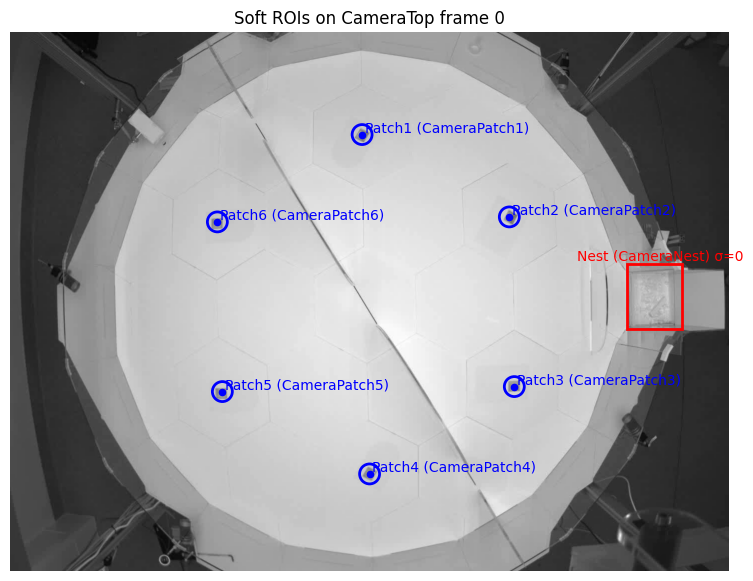

In [5]:
# Nest as rectangle ROI
nest = {
    "name": "Nest",
    "camera": "CameraNest",
    "type": "rect_center",
    "center": [1290.0, 530.0],      # (x, y) in Top pixels
    "width_px": 110.0,
    "height_px": 130.0,
    "sigma_px": 0.0,             # softness (bigger => more gradual)
    "priority": 10
}

# Patch ROIs
patches_circle = [
    {
        "name": "Patch1",
        "camera": "CameraPatch1",
        "type": "circle",
        "center": [705.0, 205.0],
        "radius_px": 20.0,
        "sigma_px": 20.0,
        "priority": 10
    },
    {
        "name": "Patch2",
        "camera": "CameraPatch2",
        "type": "circle",
        "center": [1000.0, 370.0],
        "radius_px": 20.0,
        "sigma_px": 20.0,
        "priority": 10
    },
    {
        "name": "Patch3",
        "camera": "CameraPatch3",
        "type": "circle",
        "center": [1010.0, 710.0],
        "radius_px": 20.0,
        "sigma_px": 20.0,
        "priority": 10
    },
    {
        "name": "Patch4",
        "camera": "CameraPatch4",
        "type": "circle",
        "center": [720.0, 885.0],
        "radius_px": 20.0,
        "sigma_px": 20.0,
        "priority": 10
    },
    {
        "name": "Patch5",
        "camera": "CameraPatch5",
        "type": "circle",
        "center": [425.0, 720.0],
        "radius_px": 20.0,
        "sigma_px": 20.0,
        "priority": 10
    },
    {
        "name": "Patch6",
        "camera": "CameraPatch6",
        "type": "circle",
        "center": [415.0, 380.0],
        "radius_px": 20.0,
        "sigma_px": 20.0,
        "priority": 10
    },
]

# Visualize ROIs on the Top image
def rect_corners_from_center(center, width_px, height_px):
    cx, cy = center
    x0 = cx - width_px / 2
    x1 = cx + width_px / 2
    y0 = cy - height_px / 2
    y1 = cy + height_px / 2
    return x0, y0, x1, y1


fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(top_rgb)
ax.axis("off")
ax.set_title(f"Soft ROIs on {camera_top} frame {frame_idx}")

# Nest rectangle
x0, y0, x1, y1 = rect_corners_from_center(nest["center"], nest["width_px"], nest["height_px"])
rect = patches.Rectangle((x0, y0), x1 - x0, y1 - y0, linewidth=2, edgecolor="red", facecolor="none")
ax.add_patch(rect)
ax.text(x0 - 100, y0 - 8, f'{nest["name"]} ({nest["camera"]}) σ={nest["sigma_px"]:.0f}', color="red", fontsize=10)

# Patch circles
for r in patches_circle:
    cx, cy = r["center"]
    rad = r["radius_px"]
    circ = patches.Circle((cx, cy), rad, linewidth=2, edgecolor="blue", facecolor="none")
    ax.add_patch(circ)
    ax.scatter([cx], [cy], s=20, color="blue")
    ax.text(cx + 5, cy - 5, f'{r["name"]} ({r["camera"]})', color="blue", fontsize=10)
plt.show()


### Save chosen ROIs to .json file

In [6]:
rois_out = []

# Convert nest rect_center -> explicit corners for portability
x0, y0, x1, y1 = rect_corners_from_center(nest["center"], nest["width_px"], nest["height_px"])
rois_out.append({
    "name": nest["name"],
    "camera": nest["camera"],
    "type": "rect",
    "x0y0": [float(x0), float(y0)],
    "x1y1": [float(x1), float(y1)],
    "sigma_px": float(nest["sigma_px"]),
    "priority": int(nest["priority"]),
})

# Circles 그대로 저장
for r in patches_circle:
    rois_out.append({
        "name": r["name"],
        "camera": r["camera"],
        "type": "circle",
        "center": [float(r["center"][0]), float(r["center"][1])],
        "radius_px": float(r["radius_px"]),
        "sigma_px": float(r["sigma_px"]),
        "priority": int(r["priority"]),
    })

payload = {
    "meta": {
        "experiment": experiment,
        "arena": arena,
        "session": session,
        "chunk": chunk,
        "top_camera": camera_top,
        "frame_idx_used_for_drawing": frame_idx,
        "image_shape": [int(H), int(W), int(top_rgb.shape[2])],
    },
    "rois": rois_out,
}

roi_json_path.write_text(json.dumps(payload, indent=2))
print("Saved:", roi_json_path)
print("ROIs:", [r["name"] for r in rois_out])

Saved: /Users/zosiasus/Documents/Aeon3_SLEAP/frame_mapping_output/abcEphysPilot01/soft_rois_top.json
ROIs: ['Nest', 'Patch1', 'Patch2', 'Patch3', 'Patch4', 'Patch5', 'Patch6']
